## English Premier League (EPL) Match Data 2000-2025

In [101]:
# importing the libraries 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler ,PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import ElasticNetCV,RidgeCV,LassoCV
import warnings
warnings.filterwarnings("ignore")


In [26]:
df=pd.read_csv(r"D:\Downloads\archive\epl_final.csv") # loading the dataset using csv  
df=pd.DataFrame(df) # converting the csv file in dataframe for our analysis 
print(df) 

       Season   MatchDate        HomeTeam       AwayTeam  FullTimeHomeGoals  \
0     2000/01  2000-08-19        Charlton       Man City                  4   
1     2000/01  2000-08-19         Chelsea       West Ham                  4   
2     2000/01  2000-08-19        Coventry  Middlesbrough                  1   
3     2000/01  2000-08-19           Derby    Southampton                  2   
4     2000/01  2000-08-19           Leeds        Everton                  2   
...       ...         ...             ...            ...                ...   
9375  2024/25  2025-05-04       Brentford     Man United                  4   
9376  2024/25  2025-05-04        Brighton      Newcastle                  1   
9377  2024/25  2025-05-04        West Ham      Tottenham                  1   
9378  2024/25  2025-05-04         Chelsea      Liverpool                  3   
9379  2024/25  2025-05-05  Crystal Palace  Nott'm Forest                  1   

      FullTimeAwayGoals FullTimeResult  HalfTimeHom

In [12]:
df.head() # for displaying the first 5  rows of data in our csv file 

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,...,14,4,6,6,13,12,1,2,0,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,...,10,5,7,7,19,14,1,2,0,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,...,3,9,8,4,15,21,5,3,1,0
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,1,2,A,...,4,6,5,8,11,13,1,1,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,2,0,H,...,8,6,6,4,21,20,1,3,0,0


In [14]:
df.tail() # seeing the last five rows in our data set 

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
9375,2024/25,2025-05-04,Brentford,Man United,4,3,H,2,1,H,...,6,5,7,4,8,10,0,2,0,0
9376,2024/25,2025-05-04,Brighton,Newcastle,1,1,D,1,0,H,...,2,5,1,4,15,10,2,1,0,0
9377,2024/25,2025-05-04,West Ham,Tottenham,1,1,D,1,1,D,...,2,2,1,3,18,15,2,2,0,0
9378,2024/25,2025-05-04,Chelsea,Liverpool,3,1,H,1,0,H,...,7,2,3,6,10,11,2,2,0,0
9379,2024/25,2025-05-05,Crystal Palace,Nott'm Forest,1,1,D,0,0,D,...,3,4,7,4,9,15,3,8,0,0


In [16]:
df.describe() # describing our dataset it give the mean and count and etc etc 

,FullTimeHomeGoals,FullTimeAwayGoals,HalfTimeHomeGoals,HalfTimeAwayGoals,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
count,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000
mean,1.535394,1.182623,0.688273,0.518763,13.617484,10.810661,5.973134,4.693710,6.040299,4.774733,11.276333,11.765672,1.468124,1.792431,0.062473,0.085288
std,1.305432,1.157414,0.835079,0.735357,5.356424,4.696501,3.267954,2.750045,3.110619,2.749541,3.750250,3.924179,1.217190,1.288481,0.253221,0.290183
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,10.000000,7.000000,4.000000,3.000000,4.000000,3.000000,9.000000,9.000000,1.000000,1.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,13.000000,10.000000,6.000000,4.000000,6.000000,4.000000,11.000000,12.000000,1.000000,2.000000,0.000000,0.000000
75%,2.000000,2.000000,1.000000,1.000000,17.000000,14.000000,8.000000,6.000000,8.000000,6.000000,14.000000,14.000000,2.000000,3.000000,0.000000,0.000000
max,9.000000,9.000000,5.000000,5.000000,43.000000,37.000000,24.000000,20.000000,20.000000,19.000000,33.000000,29.000000,7.000000,9.000000,3.000000,2.000000


In [18]:
df.info() # checking the information of the dataset 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9380 entries, 0 to 9379
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Season             9380 non-null   object
 1   MatchDate          9380 non-null   object
 2   HomeTeam           9380 non-null   object
 3   AwayTeam           9380 non-null   object
 4   FullTimeHomeGoals  9380 non-null   int64 
 5   FullTimeAwayGoals  9380 non-null   int64 
 6   FullTimeResult     9380 non-null   object
 7   HalfTimeHomeGoals  9380 non-null   int64 
 8   HalfTimeAwayGoals  9380 non-null   int64 
 9   HalfTimeResult     9380 non-null   object
 10  HomeShots          9380 non-null   int64 
 11  AwayShots          9380 non-null   int64 
 12  HomeShotsOnTarget  9380 non-null   int64 
 13  AwayShotsOnTarget  9380 non-null   int64 
 14  HomeCorners        9380 non-null   int64 
 15  AwayCorners        9380 non-null   int64 
 16  HomeFouls          9380 non-null   int64 


In [21]:
df.dtypes ## checking the datatype for each columns 

Season               object
MatchDate            object
HomeTeam             object
AwayTeam             object
FullTimeHomeGoals     int64
FullTimeAwayGoals     int64
FullTimeResult       object
HalfTimeHomeGoals     int64
HalfTimeAwayGoals     int64
HalfTimeResult       object
HomeShots             int64
AwayShots             int64
HomeShotsOnTarget     int64
AwayShotsOnTarget     int64
HomeCorners           int64
AwayCorners           int64
HomeFouls             int64
AwayFouls             int64
HomeYellowCards       int64
AwayYellowCards       int64
HomeRedCards          int64
AwayRedCards          int64
dtype: object

In [24]:
df.shape # checking the shape of the dataset it has 9380 rows and 22 columns 

(9380, 22)

In [29]:
df.index # checking the index range 

RangeIndex(start=0, stop=9380, step=1)

In [31]:
df.columns # important for analysis and checking the relationships 

Index(['Season', 'MatchDate', 'HomeTeam', 'AwayTeam', 'FullTimeHomeGoals',
       'FullTimeAwayGoals', 'FullTimeResult', 'HalfTimeHomeGoals',
       'HalfTimeAwayGoals', 'HalfTimeResult', 'HomeShots', 'AwayShots',
       'HomeShotsOnTarget', 'AwayShotsOnTarget', 'HomeCorners', 'AwayCorners',
       'HomeFouls', 'AwayFouls', 'HomeYellowCards', 'AwayYellowCards',
       'HomeRedCards', 'AwayRedCards'],
      dtype='object')

# we want saparate the categrical data numerical data 

In [34]:
numerical_columns=[column for column in df.columns if df[column].dtype!='O']
# its divides the numerical columns from our dataset easy to understand 

In [33]:
numerical_columns

['FullTimeHomeGoals',
 'FullTimeAwayGoals',
 'HalfTimeHomeGoals',
 'HalfTimeAwayGoals',
 'HomeShots',
 'AwayShots',
 'HomeShotsOnTarget',
 'AwayShotsOnTarget',
 'HomeCorners',
 'AwayCorners',
 'HomeFouls',
 'AwayFouls',
 'HomeYellowCards',
 'AwayYellowCards',
 'HomeRedCards',
 'AwayRedCards']

In [35]:
Categorical_columns=[column for column in df.columns if df[column].dtype == "O" ]

In [36]:
Categorical_columns

['Season',
 'MatchDate',
 'HomeTeam',
 'AwayTeam',
 'FullTimeResult',
 'HalfTimeResult']

In [40]:
df["HomeTeam"]

0             Charlton
1              Chelsea
2             Coventry
3                Derby
4                Leeds
             ...      
9375         Brentford
9376          Brighton
9377          West Ham
9378           Chelsea
9379    Crystal Palace
Name: HomeTeam, Length: 9380, dtype: object

# Data preprocessing 

In [41]:
# checking for null values and duplicates 

In [46]:
print(df.isnull()) # checking for any null values 
print(df.isna()) # checking for any na values 
print(df.notnull()) # checking for not null values 
print(df.notna()) # checking for not na values 

      Season  MatchDate  HomeTeam  AwayTeam  FullTimeHomeGoals  \
0      False      False     False     False              False   
1      False      False     False     False              False   
2      False      False     False     False              False   
3      False      False     False     False              False   
4      False      False     False     False              False   
...      ...        ...       ...       ...                ...   
9375   False      False     False     False              False   
9376   False      False     False     False              False   
9377   False      False     False     False              False   
9378   False      False     False     False              False   
9379   False      False     False     False              False   

      FullTimeAwayGoals  FullTimeResult  HalfTimeHomeGoals  HalfTimeAwayGoals  \
0                 False           False              False              False   
1                 False           False      

In [52]:
df.head()

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,...,14,4,6,6,13,12,1,2,0,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,...,10,5,7,7,19,14,1,2,0,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,...,3,9,8,4,15,21,5,3,1,0
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,1,2,A,...,4,6,5,8,11,13,1,1,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,2,0,H,...,8,6,6,4,21,20,1,3,0,0


In [57]:
print(df.dropna().sum()) # we droping the na values for our dataset 
#print(df.fillna.mean("FullTimeHomeGoals")) # if in case if their any values we are the filling the na's

Season               2000/012000/012000/012000/012000/012000/012000...
MatchDate            2000-08-192000-08-192000-08-192000-08-192000-0...
HomeTeam             CharltonChelseaCoventryDerbyLeedsLeicesterLive...
AwayTeam             Man CityWest HamMiddlesbroughSouthamptonEverto...
FullTimeHomeGoals                                                14402
FullTimeAwayGoals                                                11093
FullTimeResult       HHADHDHHHHHHDDHHHAAHDDHAAHDDDAHDHDDADHHDDAHHHA...
HalfTimeHomeGoals                                                 6456
HalfTimeAwayGoals                                                 4866
HalfTimeResult       HHDAHDDDHHHHDADHDADADHDAAHAADAHDADHAADHHDADHHH...
HomeShots                                                       127732
AwayShots                                                       101404
HomeShotsOnTarget                                                56028
AwayShotsOnTarget                                                44027
HomeCo

In [62]:
df=df.fillna(df.mean(numeric_only=True)) ## filling mean value in na in hole dataset 

In [65]:
df.isna().sum() ## see all are Zeros so no na values 

Season               0
MatchDate            0
HomeTeam             0
AwayTeam             0
FullTimeHomeGoals    0
FullTimeAwayGoals    0
FullTimeResult       0
HalfTimeHomeGoals    0
HalfTimeAwayGoals    0
HalfTimeResult       0
HomeShots            0
AwayShots            0
HomeShotsOnTarget    0
AwayShotsOnTarget    0
HomeCorners          0
AwayCorners          0
HomeFouls            0
AwayFouls            0
HomeYellowCards      0
AwayYellowCards      0
HomeRedCards         0
AwayRedCards         0
dtype: int64

In [69]:
df.isnull().sum() # see all are zerows na 

Season               0
MatchDate            0
HomeTeam             0
AwayTeam             0
FullTimeHomeGoals    0
FullTimeAwayGoals    0
FullTimeResult       0
HalfTimeHomeGoals    0
HalfTimeAwayGoals    0
HalfTimeResult       0
HomeShots            0
AwayShots            0
HomeShotsOnTarget    0
AwayShotsOnTarget    0
HomeCorners          0
AwayCorners          0
HomeFouls            0
AwayFouls            0
HomeYellowCards      0
AwayYellowCards      0
HomeRedCards         0
AwayRedCards         0
dtype: int64

In [70]:
print(df["HomeTeam"].unique())

['Charlton' 'Chelsea' 'Coventry' 'Derby' 'Leeds' 'Leicester' 'Liverpool'
 'Sunderland' 'Tottenham' 'Man United' 'Arsenal' 'Bradford' 'Ipswich'
 'Middlesbrough' 'Everton' 'Man City' 'Newcastle' 'Southampton' 'West Ham'
 'Aston Villa' 'Bolton' 'Blackburn' 'Fulham' 'Birmingham' 'West Brom'
 'Portsmouth' 'Wolves' 'Norwich' 'Crystal Palace' 'Wigan' 'Reading'
 'Sheffield United' 'Watford' 'Hull' 'Stoke' 'Burnley' 'Blackpool' 'QPR'
 'Swansea' 'Cardiff' 'Bournemouth' 'Brighton' 'Huddersfield' 'Brentford'
 "Nott'm Forest" 'Luton']


In [74]:
print(df["AwayTeam"].unique()) # it give the unique value 

['Man City' 'West Ham' 'Middlesbrough' 'Southampton' 'Everton'
 'Aston Villa' 'Bradford' 'Arsenal' 'Ipswich' 'Newcastle' 'Liverpool'
 'Chelsea' 'Man United' 'Tottenham' 'Charlton' 'Sunderland' 'Derby'
 'Coventry' 'Leicester' 'Leeds' 'Blackburn' 'Bolton' 'Fulham' 'West Brom'
 'Birmingham' 'Wolves' 'Portsmouth' 'Crystal Palace' 'Norwich' 'Wigan'
 'Watford' 'Sheffield United' 'Reading' 'Stoke' 'Hull' 'Burnley'
 'Blackpool' 'Swansea' 'QPR' 'Cardiff' 'Bournemouth' 'Huddersfield'
 'Brighton' 'Brentford' "Nott'm Forest" 'Luton']


In [76]:
df.columns

Index(['Season', 'MatchDate', 'HomeTeam', 'AwayTeam', 'FullTimeHomeGoals',
       'FullTimeAwayGoals', 'FullTimeResult', 'HalfTimeHomeGoals',
       'HalfTimeAwayGoals', 'HalfTimeResult', 'HomeShots', 'AwayShots',
       'HomeShotsOnTarget', 'AwayShotsOnTarget', 'HomeCorners', 'AwayCorners',
       'HomeFouls', 'AwayFouls', 'HomeYellowCards', 'AwayYellowCards',
       'HomeRedCards', 'AwayRedCards'],
      dtype='object')

In [77]:
print(df.groupby("HomeTeam")["FullTimeHomeGoals"].sum().sort_values(ascending=False))

HomeTeam
Arsenal             1005
Man City             984
Liverpool            972
Chelsea              965
Man United           957
Tottenham            861
Everton              712
Newcastle            673
West Ham             599
Aston Villa          564
Fulham               456
Southampton          422
Leicester            344
West Brom            292
Sunderland           288
Crystal Palace       288
Blackburn            285
Bolton               271
Wolves               250
Stoke                248
Middlesbrough        243
Bournemouth          204
Brighton             198
Leeds                186
Burnley              180
Swansea              179
Charlton             173
Portsmouth           170
Wigan                169
Birmingham           157
Watford              156
Norwich              154
Brentford            124
Hull                 107
Sheffield United      79
Nott'm Forest         78
Reading               71
Ipswich               64
QPR                   60
Derby           

In [79]:
print(df.groupby("AwayTeam")["FullTimeAwayGoals"].sum().sort_values(ascending=False))

AwayTeam
Liverpool           775
Arsenal             773
Man United          747
Chelsea             736
Man City            735
Tottenham           660
Everton             490
Newcastle           479
Aston Villa         474
West Ham            451
Southampton         317
Leicester           316
Fulham              315
Crystal Palace      276
Sunderland          232
Blackburn           223
West Brom           214
Bolton              213
Wolves              204
Bournemouth         183
Brighton            176
Leeds               175
Burnley             161
Middlesbrough       160
Stoke               150
Wigan               147
Swansea             127
Charlton            121
Watford             119
Birmingham          107
Portsmouth          107
Brentford           100
Norwich              92
Hull                 74
Ipswich              69
Reading              65
Nott'm Forest        63
QPR                  55
Sheffield United     47
Derby                35
Blackpool            25
Cardiff

In [86]:
# most winner 10 home teams 
print(df[df['FullTimeResult']=="H"].groupby("HomeTeam").size().sort_values(ascending=False).head(10))
#most Winner 10 Away teams
print("printong the top 10 AwwayTeam full timeresults:\n")
print(df[df["FullTimeResult"]=="H"].groupby("AwayTeam").size().sort_values(ascending=False).head(10))

HomeTeam
Man United     318
Arsenal        314
Liverpool      307
Chelsea        299
Man City       293
Tottenham      275
Everton        223
Newcastle      204
West Ham       170
Aston Villa    165
dtype: int64
printong the top 10 AwwayTeam full timeresults:

AwayTeam
Newcastle      213
West Ham       211
Everton        200
Tottenham      187
Aston Villa    187
Fulham         177
Southampton    162
Sunderland     156
Man City       145
Liverpool      135
dtype: int64


In [89]:
# teams that recives the most red cards at home 
print(df.groupby("HomeTeam")["HomeRedCards"].sum().sort_values(ascending=False).head(10))

HomeTeam
Everton        36
Newcastle      30
Arsenal        28
Southampton    28
Man City       28
Chelsea        27
Aston Villa    26
Fulham         26
Blackburn      22
Tottenham      22
Name: HomeRedCards, dtype: int64


## visulations

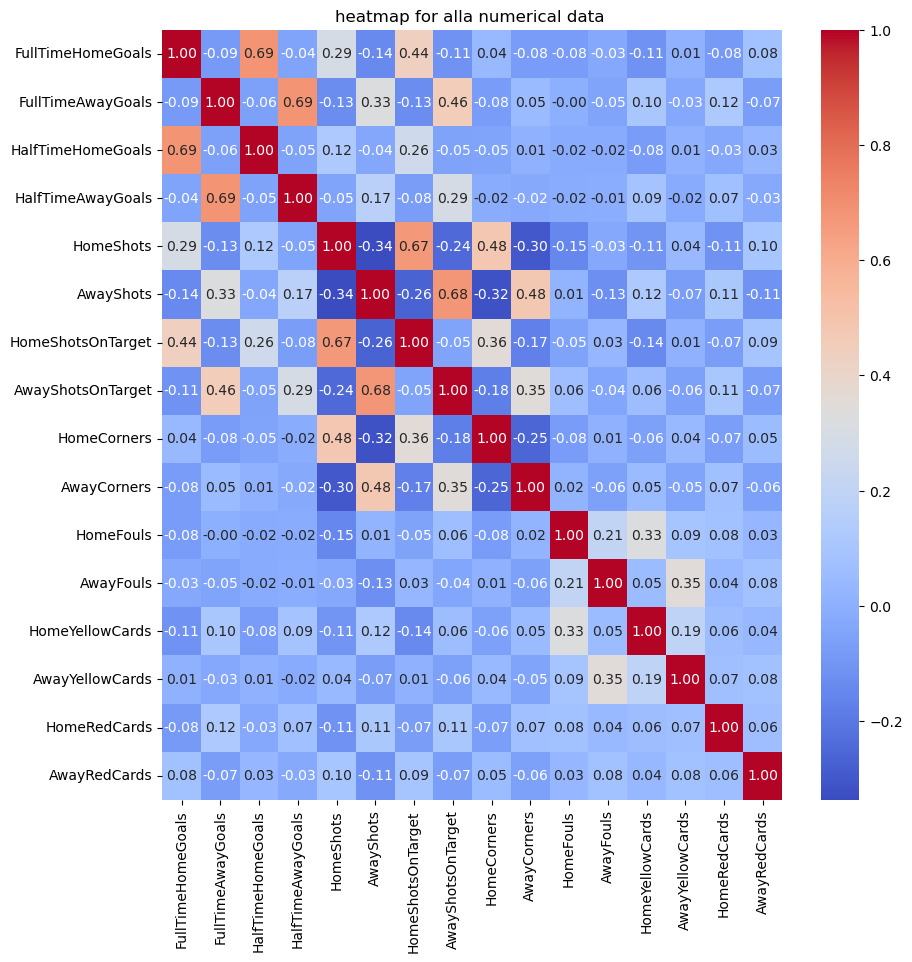

In [92]:
corr=df.corr(numeric_only=True)
plt.figure(figsize=(10,10))
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("heatmap for alla numerical data ")
plt.show()

-0.1145612459713628


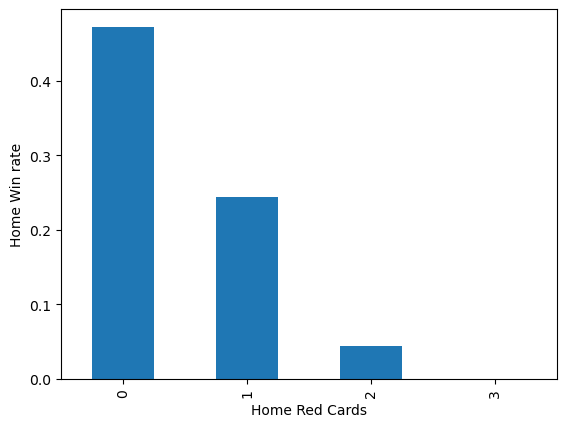

<Figure size 640x480 with 0 Axes>

In [94]:
df['HomeWin']=(df["FullTimeResult"]=="H").astype(int)
print(df["HomeRedCards"].corr(df["HomeWin"]))
df.groupby("HomeRedCards")["HomeWin"].mean().plot(kind="bar")
plt.ylabel("Home Win rate")
plt.xlabel("Home Red Cards")
plt.show()
plt.tight_layout()

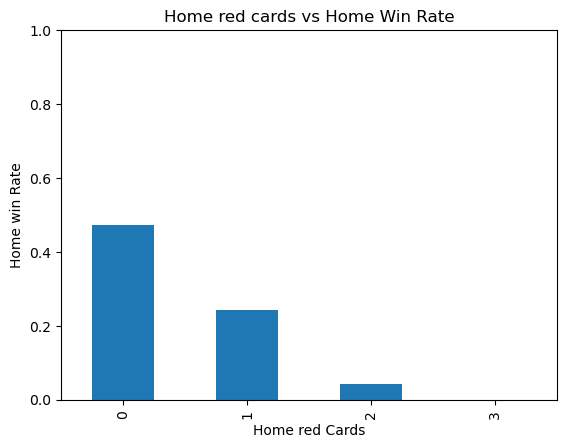

In [98]:
# average number of wins per red card 
summary=df.groupby("HomeRedCards")["HomeWin"].agg(["mean","count"])
summary["mean"].plot(kind="bar")
plt.title("Home red cards vs Home Win Rate")
plt.xlabel("Home red Cards")
plt.ylabel("Home win Rate")
plt.ylim(0,1)
plt.show()

C:\Users\putti\AppData\Local\Temp\ipykernel_12916\1956855797.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df["HomeShots"],bins=5))["HomeWin"].mean().plot(kind="bar")


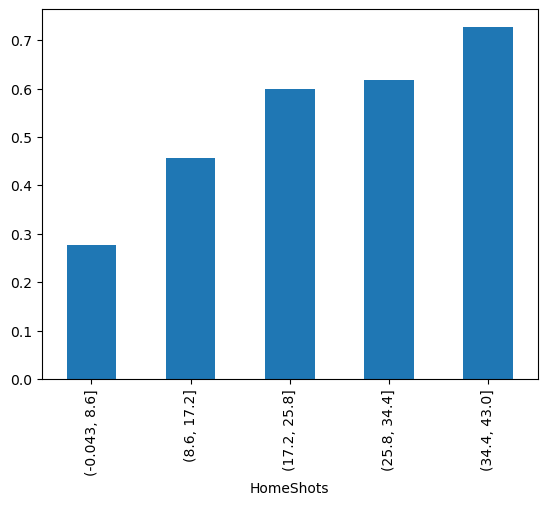

In [99]:
# the relationship betwwen shots and win 
df.groupby(pd.cut(df["HomeShots"],bins=5))["HomeWin"].mean().plot(kind="bar")
plt.show()

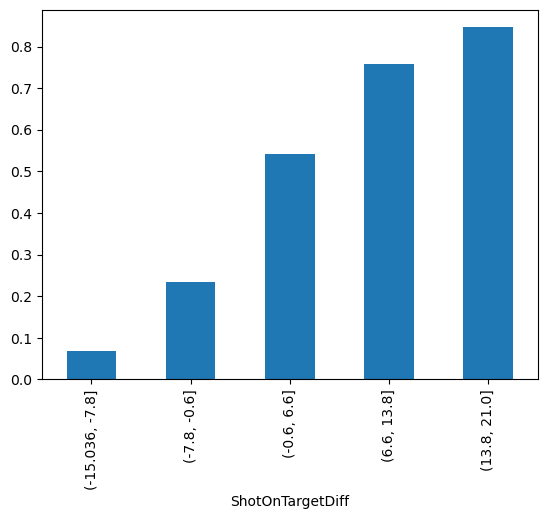

In [102]:
# shots on Target Difference
df['ShotOnTargetDiff']=df["HomeShotsOnTarget"]-df["AwayShotsOnTarget"]
df.groupby(pd.cut(df["ShotOnTargetDiff"],bins=5))["HomeWin"].mean().plot(kind="bar")
plt.show()

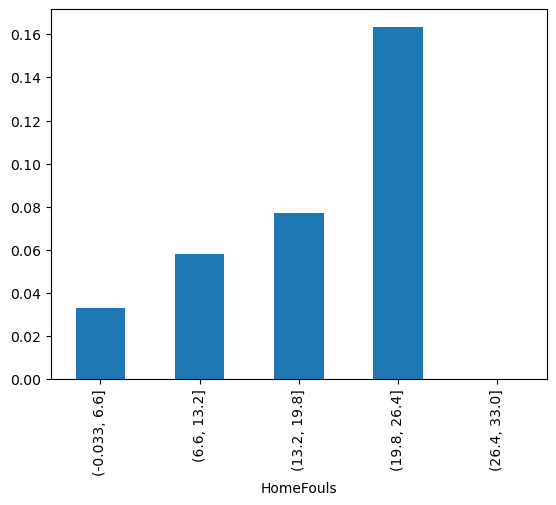

In [103]:
# The relationship between foul and card 
df.groupby(pd.cut(df["HomeFouls"],bins=5))["HomeRedCards"].mean().plot(kind="bar")
plt.show()

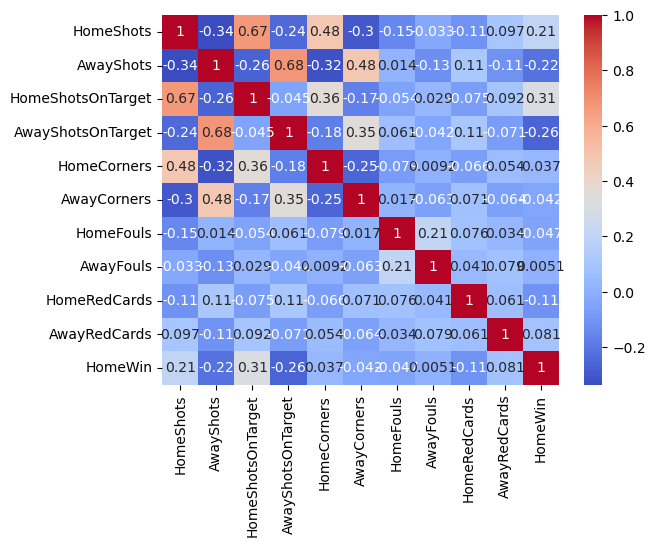

In [104]:
#Correlation
cols = [
     'HomeShots', 'AwayShots',
     'HomeShotsOnTarget', 'AwayShotsOnTarget',
     'HomeCorners', 'AwayCorners',
     'HomeFouls', 'AwayFouls',
     'HomeRedCards', 'AwayRedCards',
     'HomeWin'
 ]
sns.heatmap(df[cols].corr(),annot=True,cmap="coolwarm")
plt.show()

## Linear Regression 

In [105]:
#Dependent and Independent Features and Train Test Split For Linear Regression
df["GoalDiff"] = df["FullTimeHomeGoals"] - df["FullTimeAwayGoals"]
y = df["GoalDiff"]

# --------------------
# Features
# --------------------
X = df[
    [
        'HomeShots',
        'AwayShots',
        'HomeShotsOnTarget',
        'AwayShotsOnTarget',
        'HomeCorners',
        'AwayCorners',
        'HomeFouls',
        'AwayFouls',
        'HomeYellowCards',
        'AwayYellowCards',
        'HomeRedCards',
        'AwayRedCards'
    ]
]

# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [106]:
#LINEAR REGRESSION (SCALED)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

y_pred = linear_model.predict(X_test_scaled)

print("LINEAR REGRESSION")
print("MSE :", mean_squared_error(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("R2  :", r2_score(y_test, y_pred))

LINEAR REGRESSION
MSE : 2.238625605788915
MAE : 1.1717111649070346
R2  : 0.3162733976015425


As you see, the linear regression model shows limited explanatory power on this football dataset.

Mean Square Error(2.23) and Mean Absolute Error(1.17) values indicate that a relatively high prediction error, suggesting that match outcomes or target values cannot be well-approximated with a simple linear relationship.

Also, R2 score(0.316) means that the model explains only about 32% of the variance in the target variable.

However, this result is expected, as football data is highly non-linear and influenced by complex interactions which linear regression cannot capture effectively.

Now, let's build the model using polynomial regression and examine the values.

In [107]:
poly = PolynomialFeatures(degree=3, include_bias=False)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)

print("\nPOLYNOMIAL REGRESSION (degree=3)")
print("MSE :", mean_squared_error(y_test, y_pred_poly))
print("MAE :", mean_absolute_error(y_test, y_pred_poly))
print("R2  :", r2_score(y_test, y_pred_poly))


POLYNOMIAL REGRESSION (degree=3)
MSE : 2.4105290019722405
MAE : 1.190106103839595
R2  : 0.26377023462992055


As you see, polynomial regression did not improve performance because the underlying relationships in football data are not smooth polynomial functions. Instead, match outcomes depend on threshold-based and interaction-driven effects, which polynomial expansion fails to capture.

Now,let's build the model using polynomial regression and examine the values.

Mean Absolute Error:  1.1716745941981854
Mean Squared Error:  2.2385439720018385
R2 Score:  0.3162983303959026


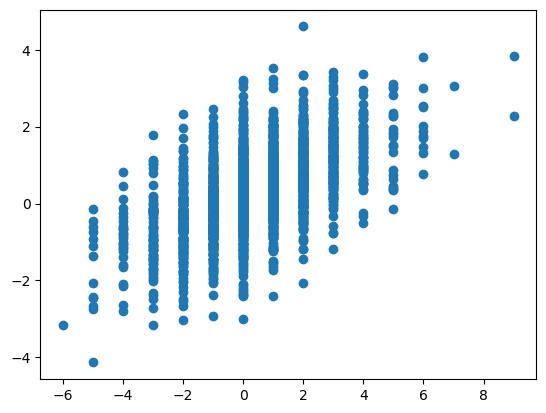

In [108]:
#LassoCV

df["GoalDiff"] = df["FullTimeHomeGoals"] - df["FullTimeAwayGoals"]
y = df["GoalDiff"]

# --------------------
# Features
# --------------------
X = df[
    [
        'HomeShots',
        'AwayShots',
        'HomeShotsOnTarget',
        'AwayShotsOnTarget',
        'HomeCorners',
        'AwayCorners',
        'HomeFouls',
        'AwayFouls',
        'HomeYellowCards',
        'AwayYellowCards',
        'HomeRedCards',
        'AwayRedCards'
    ]
]

# --------------------
# Train / Test Split
# --------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

scaler = StandardScaler()

X_train_Scaled = scaler.fit_transform(X_train)

X_test_Scaled = scaler.transform(X_test)


lassocv = LassoCV(cv=5)
lassocv.fit(X_train_Scaled, y_train)
y_pred = lassocv.predict(X_test_Scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean Absolute Error: ", mae)
print("Mean Squared Error: ", mse)
print("R2 Score: ", score)
plt.scatter(y_test, y_pred)
plt.show()

Mean Absolute Error:  1.171665812475174
Mean Squared Error:  2.238572622825833
R2 Score:  0.31628957978995276


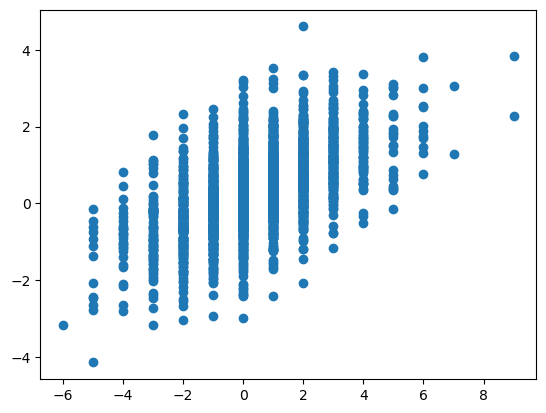

In [109]:
#RidgeCV

ridgecv = RidgeCV(cv=5)
ridgecv.fit(X_train_Scaled, y_train)
y_pred = ridgecv.predict(X_test_Scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean Absolute Error: ", mae)
print("Mean Squared Error: ", mse)
print("R2 Score: ", score)
plt.scatter(y_test, y_pred)
plt.show()

Mean Absolute Error:  1.1716533392647521
Mean Squared Error:  2.238523173354468
R2 Score:  0.31630468277053125


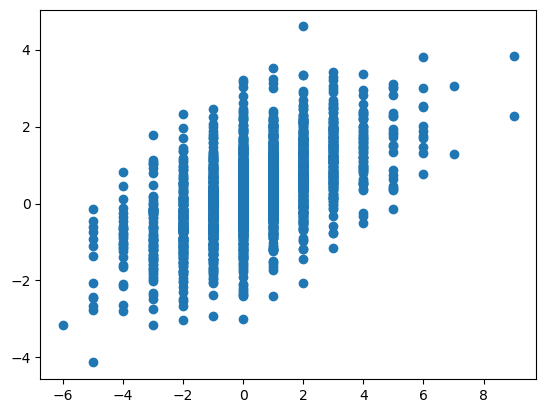

In [110]:
#ElasticNetCV

elasticcv = ElasticNetCV(cv=5)
elasticcv.fit(X_train_Scaled, y_train)
y_pred = elasticcv.predict(X_test_Scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean Absolute Error: ", mae)
print("Mean Squared Error: ", mse)
print("R2 Score: ", score)
plt.scatter(y_test, y_pred)
plt.show()

Regularized linear models (RidgeCV, LassoCV, ElasticNetCV) achieved similar R2 scores (0.32), indicating that performance is limited by feature representation rather than model choice. This suggests that further gains require better feature engineering or non-linear models.

Tree-based models such as Decision Trees and Random Forests are better suited for football data because they naturally capture feature interactions. Unlike linear models, they do not assume a smooth relationship between inputs and outputs, making them more effective for complex, rule domains like sports analytics